In [1]:
import sys
sys.path.append('../')

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np

import matplotlib.pyplot as plt

# Dataset

In [2]:
from train import get_data

data_file_path = "/storage/agrp/dreyet/FastCaloSim/Geant4/B4/build/B4c/electron_showers_5GeV_10k_128_128_64.root"

splits = {'train': 0.2, 'val': 0.02, 'test': 0.0}

dataset, dls = get_data(data_file_path, splits, batch_size=256)

Dataset sizes:
{'train': 2000, 'val': 200, 'test': 0}


Low-res shape: torch.Size([1, 64, 64])
High-res shape: torch.Size([1, 128, 128])


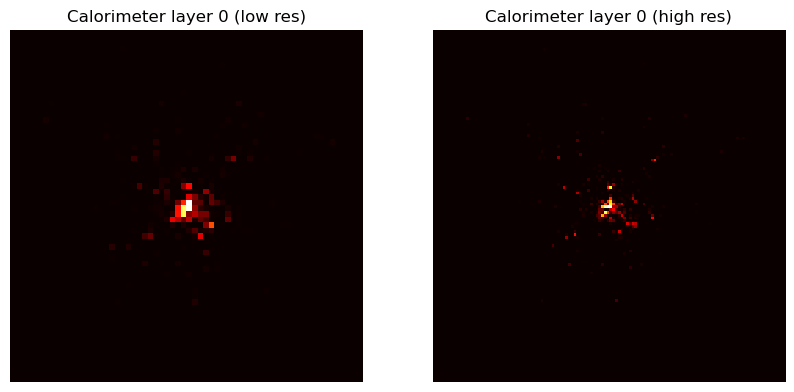

In [3]:
example_idx = 1
layer_idx = 0

x_low = dataset[example_idx]
x_high = dataset.__getitem__(example_idx, downsample=False)

print(f"Low-res shape: {x_low.shape}")
print(f"High-res shape: {x_high.shape}")

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(x_low[layer_idx, :, :].numpy(), cmap='hot', interpolation='none')
ax[0].set_title(f'Calorimeter layer {layer_idx} (low res)')
ax[0].axis('off')

ax[1].imshow(x_high[layer_idx, :, :].numpy(), cmap='hot', interpolation='none')
ax[1].set_title(f'Calorimeter layer {layer_idx} (high res)')
ax[1].axis('off')

plt.show()

# Model

In [5]:
n_x = 64
dims = [n_x, n_x]

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# FNO hyperparameters
modes = 32 
width = 128
mlp_width = 128

# GP hyperparameters
kernel_length=0.01
kernel_variance=1
nu = 0.5 # default

## training parameters
Ntrain = 2560
epochs = 100
sigma_min=1e-4
batch_size = 256

Using device: cuda:1


In [6]:
from models.fno import FNO

model = FNO(modes, vis_channels=1, hidden_channels=width, proj_channels=mlp_width, x_dim=2, t_scaling=1).to(device)

# Training

In [7]:
dataset_tr = Subset(dataset, np.arange(1000))
loader_tr = DataLoader(dataset_tr, batch_size=batch_size, shuffle=True)

In [8]:
from ofm_OT_likelihood import OFMModel

fmot = OFMModel(model, kernel_length=kernel_length, kernel_variance=kernel_variance, nu=nu, sigma_min=sigma_min, device=device, dims=dims)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=epochs//10, gamma=0.8)

In [11]:
nparam = [p.numel() for p in fmot.model.parameters() if p.requires_grad]
print(f"Number of trainable parameters: {np.sum(nparam)}")

Number of trainable parameters: 35852417


In [10]:
from pathlib import Path
save_path = Path(".")

fmot.train(loader_tr, optimizer, epochs=epochs, scheduler=scheduler, eval_int=int(0), save_int=int(2), generate=False, save_path=save_path,saved_model=True)

tr @ epoch 1/100 | Loss 4.309810 | 5.18 (s)
tr @ epoch 2/100 | Loss 2.748680 | 4.89 (s)
tr @ epoch 3/100 | Loss 2.297354 | 4.87 (s)
tr @ epoch 4/100 | Loss 2.059089 | 4.87 (s)
tr @ epoch 5/100 | Loss 1.835575 | 4.86 (s)
tr @ epoch 6/100 | Loss 1.469389 | 4.84 (s)
tr @ epoch 7/100 | Loss 1.309329 | 4.85 (s)
tr @ epoch 8/100 | Loss 1.213517 | 4.84 (s)
tr @ epoch 9/100 | Loss 1.197872 | 4.86 (s)
tr @ epoch 10/100 | Loss 1.012399 | 4.87 (s)
tr @ epoch 11/100 | Loss 1.132452 | 4.89 (s)
tr @ epoch 12/100 | Loss 1.056501 | 4.86 (s)
tr @ epoch 13/100 | Loss 0.905385 | 4.89 (s)
tr @ epoch 14/100 | Loss 0.877294 | 4.87 (s)
tr @ epoch 15/100 | Loss 0.822930 | 4.89 (s)
tr @ epoch 16/100 | Loss 0.784216 | 4.87 (s)
tr @ epoch 17/100 | Loss 0.710348 | 4.88 (s)
tr @ epoch 18/100 | Loss 0.727718 | 4.86 (s)
tr @ epoch 19/100 | Loss 0.646487 | 4.88 (s)
tr @ epoch 20/100 | Loss 0.621940 | 4.87 (s)
tr @ epoch 21/100 | Loss 0.544674 | 4.88 (s)
tr @ epoch 22/100 | Loss 0.519013 | 4.88 (s)
tr @ epoch 23/100 |

# Load trained model

In [5]:
from train import get_model
from ofm_OT_likelihood import OFMModel


fmot = get_model()
model = fmot.model

for param in model.parameters():
    param.requires_grad = False

from neuralop.layers.spectral_convolution import SpectralConv
torch.serialization.add_safe_globals([torch._C._nn.gelu])
torch.serialization.add_safe_globals([SpectralConv])
model_path = '../model_checkpoints/epoch_98.pt'
checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

if '_metadata' in state_dict:
    del state_dict['_metadata']

model.load_state_dict(state_dict)

Using device: cuda
Number of trainable parameters: 35852417


<All keys matched successfully>

# Evaluation

In [6]:
from scipy.stats import binned_statistic

def compute_acovf(z, nlag=50):
    # z shape : [n, ndim, ndim]
    res = z.shape[-1]
    z_hat = torch.fft.rfft2(z)
    acf = torch.fft.irfft2(torch.conj(z_hat) * z_hat)
    acf = torch.fft.fftshift(acf).mean(dim=0) / z[0].numel() # ndim*ndim
    acf_r = acf.view(-1).cpu().detach().numpy()
    lags_x, lags_y = torch.meshgrid(torch.arange(res) - res//2, torch.arange(res) - res//2)
    lags_r = torch.sqrt(lags_x**2 + lags_y**2).view(-1).cpu().detach().numpy()

    idx = np.argsort(lags_r)
    lags_r = lags_r[idx]
    acf_r = acf_r[idx]

    bin_means, bin_edges, binnumber = binned_statistic(lags_r, acf_r, 'mean', bins=np.linspace(0.0, res, nlag))
    return bin_edges[:-1], bin_means

In [7]:
x_train = torch.stack([dataset[i] for i in range(10)], dim=0)
print(x_train.shape)

torch.Size([10, 1, 64, 64])


0
1
2
3
4


/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


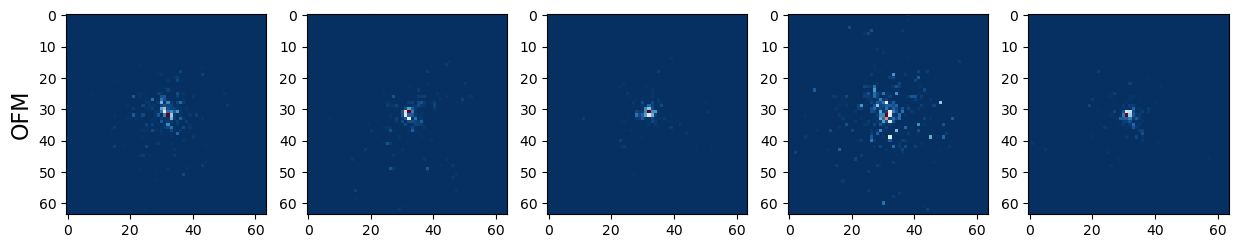

In [9]:
n_samples = 100
n_x_sample = 64

with torch.no_grad():

    X_hat = fmot.sample([n_x_sample, n_x_sample], n_samples=n_samples, n_eval=10).cpu()
    X_ground_truth = x_train[:5].squeeze()
    # plot
    
    X_alt = []
    for i in range(5):
        print(i)
        X_temp = fmot.sample([n_x_sample, n_x_sample], n_samples=n_samples, n_eval=10).cpu().squeeze()
        X_alt.append(X_temp)
        
    X_alt = torch.vstack(X_alt)
    #X_alt = torch.exp(X_alt * x_std + x_mean)
    
    bin_center, x_acovf = compute_acovf(X_alt.squeeze())
    #x_train = torch.exp(x_train*x_std + x_mean)
    _, x_acovf_true = compute_acovf(x_train.squeeze())
    x_hist, bin_edges_alt = X_alt.histogram(range=[-4,4], density=True)
    x_hist_true, bin_edges = x_train.histogram(range=[-4, 4], density=True)
    
    fig, ax = plt.subplots(1,5, figsize=(15,3))
    for i in range(5):
        x = X_hat[i,:,:].squeeze()

        ax[i].imshow(x,cmap="RdBu_r")#, vmin=-2, vmax=2)
        if i == 0:
            ax[i].set_ylabel('OFM', fontsize=16)

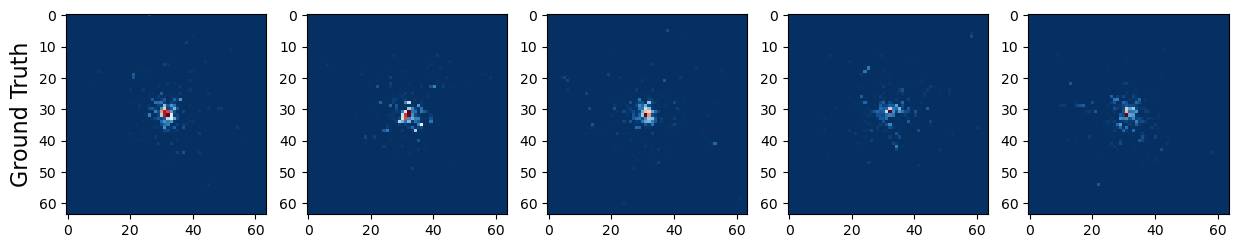

In [10]:
fig, ax = plt.subplots(1,5, figsize=(15,3))    
for i in range(5):
    x_ground_truth = X_ground_truth[i,:,:].squeeze()
    ax[i].imshow(x_ground_truth,cmap="RdBu_r")#, vmin=-2, vmax=2)
    if i == 0:
        ax[i].set_ylabel('Ground Truth', fontsize=16)


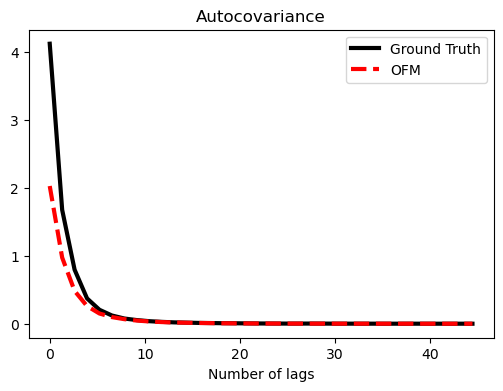

In [11]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(bin_center, x_acovf_true, c='k', lw=3, label='Ground Truth')
ax.plot(bin_center, x_acovf, c='r',ls='--', lw=3, label='OFM')
#ax[0].set_ylim(0.2, 0.45)
ax.set_title('Autocovariance')
ax.set_xlabel('Number of lags')
ax.legend(loc='upper right')